# MA2008B — Ejercicio en notebook  
## Machine Learning como problema de optimización: pérdidas y riesgo empírico

**Duración sugerida:** 30–40 minutos  
**Modalidad:** individual o equipos de 2–3 estudiantes  
**Producto:** matriz comparativa de pérdidas y justificación

### Objetivos del ejercicio

Al finalizar, el estudiante deberá poder:

1. Calcular errores de predicción.
2. Comparar MAE, MSE y RMSE.
3. Analizar el efecto de un outlier sobre distintas funciones de pérdida.
4. Calcular log loss y hinge loss en un ejemplo de clasificación.
5. Justificar qué pérdida usar según el problema.

## 1. Importar librerías

Ejecuta la siguiente celda.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.precision", 4)

# Parte A — Regresión: comparación entre MAE, MSE y RMSE

Se tiene una variable real \(y_i\) y dos modelos predictivos: Modelo A y Modelo B.

El Modelo A predice bien la mayoría de observaciones, pero falla mucho en un punto extremo.  
El Modelo B comete errores moderados, pero más uniformes.

La pregunta central es:

> ¿Cuál modelo es mejor? La respuesta depende de la pérdida elegida.

In [2]:
# Datos observados y predicciones de dos modelos

datos = pd.DataFrame({
    "observacion": [1, 2, 3, 4, 5],
    "y_real": [10, 12, 13, 15, 100],
    "y_hat_A": [11, 13, 14, 16, 80],
    "y_hat_B": [5, 7, 8, 10, 95]
})

datos

,observacion,y_real,y_hat_A,y_hat_B
0,1,10,11,5
1,2,12,13,7
2,3,13,14,8
3,4,15,16,10
4,5,100,80,95


## 2. Calcular errores

Recuerda:

$$
e_i = y_i - \hat{y}_i
$$

Calcula los errores de ambos modelos.

In [4]:
datos["error_A"] = datos["y_real"] - datos["y_hat_A"]
datos["error_B"] = datos["y_real"] - datos["y_hat_B"]

datos

,observacion,y_real,y_hat_A,y_hat_B,error_A,error_B
0,1,10,11,5,-1,5
1,2,12,13,7,-1,5
2,3,13,14,8,-1,5
3,4,15,16,10,-1,5
4,5,100,80,95,20,5


## 3. Implementar funciones de pérdida para regresión

Completa las siguientes funciones:

$$
MAE = \frac{1}{n}\sum_{i=1}^n |y_i-\hat{y}_i|
$$

$$
MSE = \frac{1}{n}\sum_{i=1}^n (y_i-\hat{y}_i)^2
$$

$$
RMSE = \sqrt{MSE}
$$

In [ ]:
def mae(y, y_hat):
    """
    Calcula Mean Absolute Error.
    """
    y = np.array(y)
    y_hat = np.array(y_hat)

    n = y.shape[0]

    return np.sum(np.abs([y[i] - y_hat[i] for i in range(n)]))/n

def mse(y, y_hat):
    """
    Calcula Mean Squared Error.
    """

    y = np.array(y)
    y_hat = np.array(y_hat)
    
    n = y.shape[0]
    
    return np.sum(np.square([y[i] - y_hat[i] for i in range(n)]))/n


def rmse(y, y_hat):
    """
    Calcula Root Mean Squared Error.
    """
    y = np.array(y)
    y_hat = np.array(y_hat)
    
    
    n = y.shape[0]
    
    return np.pow(np.sum(np.square([y[i] - y_hat[i] for i in range(n)]))/n, 1/2)

## 4. Evaluar ambos modelos

Usa tus funciones para comparar Modelo A y Modelo B.

In [15]:
y = datos["y_real"].to_numpy()
y_hat_A = datos["y_hat_A"].to_numpy()
y_hat_B = datos["y_hat_B"].to_numpy()

resultados_regresion = pd.DataFrame({
    "modelo": ["A", "B"],
    "MAE": [mae(y, y_hat_A), mae(y, y_hat_B)],
    "MSE": [mse(y, y_hat_A), mse(y, y_hat_B)],
    "RMSE": [rmse(y, y_hat_A), rmse(y, y_hat_B)]
})

resultados_regresion

,modelo,MAE,MSE,RMSE
0,A,4.8,80.8,8.9889
1,B,5.0,25.0,5.0000


## 5. Visualizar el efecto del outlier

Ejecuta la siguiente celda y observa cómo el punto extremo afecta a cada modelo.

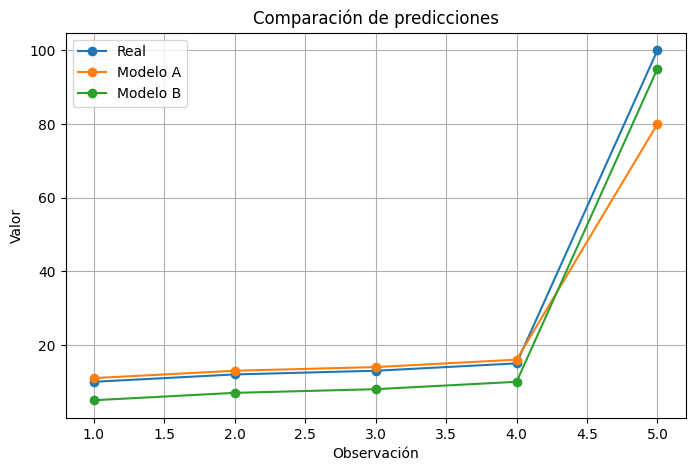

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(datos["observacion"], datos["y_real"], marker="o", label="Real")
plt.plot(datos["observacion"], datos["y_hat_A"], marker="o", label="Modelo A")
plt.plot(datos["observacion"], datos["y_hat_B"], marker="o", label="Modelo B")
plt.xlabel("Observación")
plt.ylabel("Valor")
plt.title("Comparación de predicciones")
plt.legend()
plt.grid(True)
plt.show()

## 6. Preguntas de análisis

Responde en una celda de markdown debajo:

1. ¿Cuál modelo tiene menor MAE?
2. ¿Cuál modelo tiene menor MSE?
3. ¿Cuál modelo tiene menor RMSE?
4. ¿Por qué MSE y RMSE reaccionan distinto que MAE?
5. Si el valor 100 fuera un error de captura, ¿qué modelo preferirías?
6. Si el valor 100 fuera un evento real importante, ¿qué modelo preferirías?

In [ ]:
# Escribe aquí tus respuestas como comentarios o agrega una celda Markdown debajo.

# 1. El modelo A tiene menor MAE.
# 2. El modelo B tiene menor MSE.
# 3. El modelo B tiene menor RMSE.
# 4. El mean square error (MSE), y por lo tanto RMSE, son diferentes en el sentido que penalizan más errores más graves (al estar al cuadrado, si un error era de 5, ahora es 25). Por eso el modelo B, que es un overfit claro al outlier, recibe una puntuación más baja: el modelo apuntó a un error constante entre los puntos.
# 5. El modelo A sería mi candidato pues hizo menor over-fit, el modelo B ajustó demasiado sus predicciones para compensar el 100.
# 6. Igualmente preferiría el modelo A: pues en dado caso, sigue siendo un outlier difícil de predecir. Es decir, nuestro modelo captura la tendencia de la serie (sea error humano u outlier de la vida real). 

# Parte B — Riesgo empírico

El riesgo empírico es el promedio de las pérdidas sobre el conjunto de entrenamiento:

$$
R_{\text{emp}}(\theta)=\frac{1}{n}\sum_{i=1}^{n}L(y_i,f(x_i;\theta))
$$

En esta parte se calculará el riesgo empírico usando pérdida cuadrática.

In [17]:
def riesgo_empirico_mse(y, y_hat):
    """
    Calcula el riesgo empírico usando pérdida cuadrática.
    En este caso coincide con MSE.
    """
    # Como es lo mismo que el MSE porque L lo definimos como una diferencia cuadrada, simplemente llamaré a la función.
    return mse(y, y_hat)

riesgo_A = riesgo_empirico_mse(y, y_hat_A)
riesgo_B = riesgo_empirico_mse(y, y_hat_B)

print("Riesgo empírico MSE - Modelo A:", riesgo_A)
print("Riesgo empírico MSE - Modelo B:", riesgo_B)

Riesgo empírico MSE - Modelo A: 80.8
Riesgo empírico MSE - Modelo B: 25.0


## Pregunta

Según el riesgo empírico con pérdida cuadrática:

> ¿Qué modelo seleccionaría el proceso de optimización?

In [18]:
# Respuesta: Basandome únicamente en el riesgo empírico, eligiría el modelo B.

# Parte C — Clasificación: log loss

Ahora considera un problema de clasificación binaria:

$$
y_i \in \{0,1\}
$$

El modelo no produce directamente una clase, sino una probabilidad estimada:

$$
\hat{p}_i = P(y_i=1|x_i)
$$

La log loss para clasificación binaria es:

$$
L(y,\hat{p}) =
-
\left[
y\log(\hat{p}) + (1-y)\log(1-\hat{p})
\right]
$$

In [ ]:
clasificacion = pd.DataFrame({
    "observacion": [1, 2, 3, 4, 5, 6],
    "y_real": [1, 0, 1, 1, 0, 0],
    "p_hat_modelo_1": [0.90, 0.20, 0.80, 0.55, 0.30, 0.10],
    "p_hat_modelo_2": [0.60, 0.40, 0.99, 0.01, 0.20, 0.30]
})

clasificacion

## 7. Implementar log loss

Precaución numérica: si $\hat{p}$ es exactamente 0 o 1, el logaritmo puede causar problemas.  
Por eso se recorta la probabilidad con un valor pequeño $\epsilon$.

In [22]:
def log_loss_binaria(y, p_hat, eps=1e-15):
    """
    Calcula log loss binaria promedio.
    """
    y = np.array(y)
    p_hat = np.array(p_hat)

    # Evitar log(0)
    p_hat = np.clip(p_hat, eps, 1 - eps)

    return np.sum((y*np.log(p_hat) + (1-y)*np.log(1-p_hat)))/-y.shape[0]

In [23]:
y_clf = clasificacion["y_real"].to_numpy()
p1 = clasificacion["p_hat_modelo_1"].to_numpy()
p2 = clasificacion["p_hat_modelo_2"].to_numpy()

resultados_log_loss = pd.DataFrame({
    "modelo": ["Modelo 1", "Modelo 2"],
    "log_loss": [
        log_loss_binaria(y_clf, p1),
        log_loss_binaria(y_clf, p2)
    ]
})

resultados_log_loss

,modelo,log_loss
0,Modelo 1,0.2686
1,Modelo 2,1.0361


## 8. Preguntas de análisis sobre log loss

Responde:

1. ¿Cuál modelo tiene menor log loss?
2. Observa la cuarta observación. El valor real es $y=1$, pero el Modelo 2 predice $\hat{p}=0.01$. ¿Qué efecto tiene esto?
3. ¿Por qué log loss castiga fuertemente la sobreconfianza incorrecta?

In [30]:
# Respuestas:
# 1. El modelo 1 tiene menor log loss.
# 2. Log loss lo castiga fuertemente pues es un logaritmo cercano a 0.
# 3. Por la naturaleza de los logaritmos, valores cercanos a 0 reciben un valor muy negativo, y los valores cercanos a 1 una compensasión de casi 0. 

# Parte D — Clasificación por margen: hinge loss

La hinge loss se usa frecuentemente en clasificadores tipo SVM.

Para etiquetas:

$$
y_i \in \{-1,1\}
$$

y puntaje del modelo $s_i$, la pérdida es:

$$
L(y_i,s_i)=\max(0,1-y_i s_i)
$$

Si $y_i s_i \geq 1$, el punto está correctamente clasificado con margen suficiente y la pérdida es cero.

In [32]:
margen = pd.DataFrame({
    "observacion": [1, 2, 3, 4, 5],
    "y_real": [1, 1, -1, -1, 1],
    "score_modelo": [2.0, 0.4, -1.5, 0.2, -0.8]
})

margen

,observacion,y_real,score_modelo
0,1,1,2.0
1,2,1,0.4
2,3,-1,-1.5
3,4,-1,0.2
4,5,1,-0.8


## 9. Implementar hinge loss

In [35]:
def hinge_loss(y, score):
    """
    Calcula la hinge loss promedio.
    """
    y = np.array(y)
    score = np.array(score)
    n = y.shape[0]

    return np.sum([max(0, 1 - y[i]*score[i]) for i in range(n)])/n
    

perdida_hinge = hinge_loss(
    margen["y_real"].to_numpy(),
    margen["score_modelo"].to_numpy()
)

print("Hinge loss promedio:", perdida_hinge)

Hinge loss promedio: 0.72


In [36]:
# Opcional: calcular pérdida por observación para interpretar cada caso.

margen["producto_y_score"] = margen["y_real"] * margen["score_modelo"]
margen["hinge_individual"] = [max(0, 1 - prod) for prod in margen["producto_y_score"]]

margen

,observacion,y_real,score_modelo,producto_y_score,hinge_individual
0,1,1,2.0,2.0,0.0
1,2,1,0.4,0.4,0.6
2,3,-1,-1.5,1.5,0.0
3,4,-1,0.2,-0.2,1.2
4,5,1,-0.8,-0.8,1.8


## 10. Preguntas de análisis sobre hinge loss

1. ¿Qué observaciones tienen pérdida cero?
2. ¿Qué observaciones están mal clasificadas?
3. ¿Qué observaciones están bien clasificadas pero no tienen margen suficiente?
4. ¿Por qué hinge loss no se interpreta como probabilidad?

In [ ]:
# Respuestas:
# 1. Las observaciones donde el modelo clasificó más abajo o más arriba del punto (para negativos y positivos, respectivamente.)
# 2. La 4 y 5 están mal, pues el modelo pensó otra cosa.
# 3. La observación bien clasificada pero sin márgen es la 2: el modelo estimoó encima de 0, pero no sobreestimó. 
# 4. Porque hay valores negativos y mayores a 1.

# Parte E — Producto final

Completa la siguiente matriz comparativa.

| Pérdida | Tipo de problema | Fórmula | Ventaja | Desventaja | Sensibilidad a outliers | ¿Cuándo usarla? |
|---|---|---|---|---|---|---|
| MSE | Regresión | Promedio de los errores al cuadrado.| Penaliza errores grandes | Un outlier genuino puede dar un mal score al modelo | Alta | Cuando los errores grandes cuestan. |
| MAE | Regresión | Promedio de los errores absolutos.| Bueno cuando hay errores de medición | Si hay outliers o errores grandes no los penaliza tanto | Mediana | Cuando hay varios outliers |
| RMSE | Regresión | Raíz del MSE. | Fácil interpretación. | Inútil | Mediana | Yo la neta nunca. |
| Log loss | Clasificación | La suma de las clasificaciones, ponderadas por el logaritmo de su probabilidad.| Penaliza altamente probabilidades alejadas de la clasificación real. | Un mal cálculo puede evaluar mal a tu modelo | Alta | Cuando las probabilidades deben de ser precisas |
| Hinge loss | Clasificación | El máximo de pérdida entre el producto de la clasificación y el estimado.| Perdona la sobreestimación. | Penaliza fuerte el subestimar. | Baja | Cuando es importante que el modelo NO SUBESTIME. |

Después responde:

> En un problema donde hay datos atípicos por errores de captura, ¿qué pérdida usarías y por qué? Con una pérdida de MAE funciona, pues le da el peso mínimo a los errores.

> En un problema donde los errores grandes son muy costosos, ¿qué pérdida usarías y por qué?
Pudiera usar el MSE que castiga fuertemente los errores.

> En un problema de clasificación donde necesitas probabilidades bien calibradas, ¿qué pérdida usarías y por qué?
La log loss me gusta porque si el modelo no está seguro, y arroja una probabildiad insegura o incierta lo castigamos fuertemente.